# Per-shot detector reconstruction from droplet2photon results

Reconstructs per-shot 2D images for `epix100_0` (spectroscopy) and `epix100_1` (SEER)
from the sparse single-photon positions written by the smd_producer `droplet2Photons`
pipeline (`mfx101609126_Run0079.h5`).

The photon coordinates are stored on the **full epix100 panel** (704 x 768), with
`data` = photon count per pixel. `DropletReconstructor` scatters them back into a
dense image and (optionally) crops to the ROI window used by the XES pipeline.

Two storage layouts are handled transparently:
* fixed-length zero-padded (`epix100_0`): valid entries where `data != 0`
* variable-length packed (`epix100_1`): flat arrays + per-shot `_sparse_len`

In [1]:
import importlib
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Reload so edits to droplet_reconstruct.py take effect without restarting the
# kernel (Jupyter caches imports; a stale copy causes spurious
# 'No droplet2phot sparse data found' KeyErrors).
import droplet_reconstruct
importlib.reload(droplet_reconstruct)
from droplet_reconstruct import DropletReconstructor, ROIS, PANEL_SHAPE

SMD_PATH = '/sdf/data/lcls/ds/mfx/mfx101609126/hdf5/smalldata/mfx101609126_Run0079.h5'

rec = DropletReconstructor(SMD_PATH)

# xray-on shot indices (matches the XES pipeline's 2843-shot selection)
with h5py.File(SMD_PATH, 'r') as f:
    xray = f['lightStatus/xray'][:].astype(bool)
xray_idx = np.where(xray)[0]
print(f'{xray_idx.size} xray-on shots of {xray.size} total')
print('ROI windows (row0, row1, col0, col1):', ROIS)

2843 xray-on shots of 35998 total
ROI windows (row0, row1, col0, col1): {'epix100_0': (270, 330, 400, 700), 'epix100_1': (350, 450, 80, 700)}


## 1. Reconstruct a single shot

`reconstruct_shot(det, shot_index, roi=...)` returns a 2D photon-count image.
Pass `roi=None` for the full panel, or `roi=ROIS[det]` to crop to the XES window.

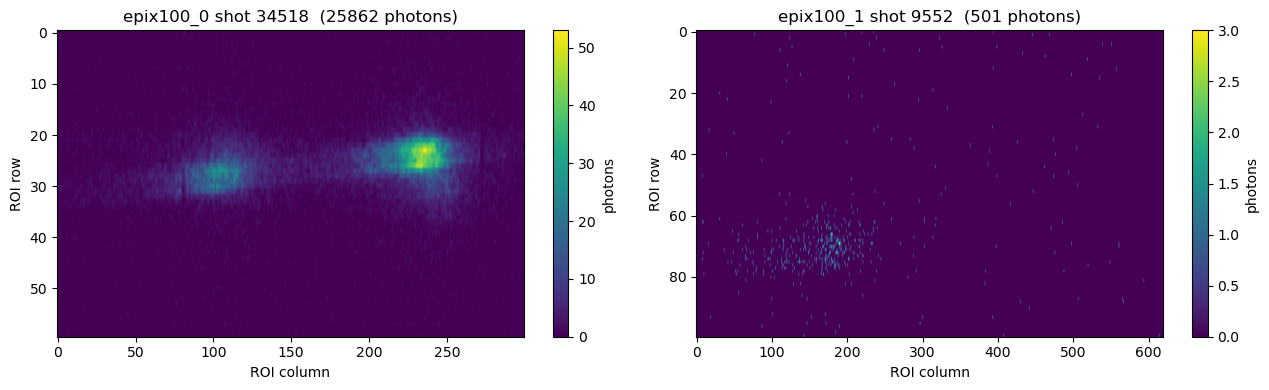

In [2]:
# Pick the busiest xray-on shot per detector for a clear example
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, det in zip(axes, ['epix100_0', 'epix100_1']):
    nd = rec.f[f'{det}/droplet_nDroplets'][:]
    nd_xray = nd.copy(); nd_xray[~xray] = 0
    shot = int(np.argmax(nd_xray))
    img = rec.reconstruct_shot(det, shot, roi=ROIS[det])
    im = ax.imshow(img, aspect='auto', cmap='viridis')
    ax.set_title(f'{det} shot {shot}  ({int(img.sum())} photons)')
    ax.set_xlabel('ROI column'); ax.set_ylabel('ROI row')
    plt.colorbar(im, ax=ax, label='photons')
plt.tight_layout(); plt.show()

## 2. Verify against `ROI_area`

The reconstructed photon image should be spatially co-located with the stored
ADU-thresholded `ROI_area` intensity. We sum a subset of shots and compare
(2D Pearson correlation over all ROI pixels).

epix100_0: 2D spatial correlation = 0.9995
epix100_1: 2D spatial correlation = 0.9730


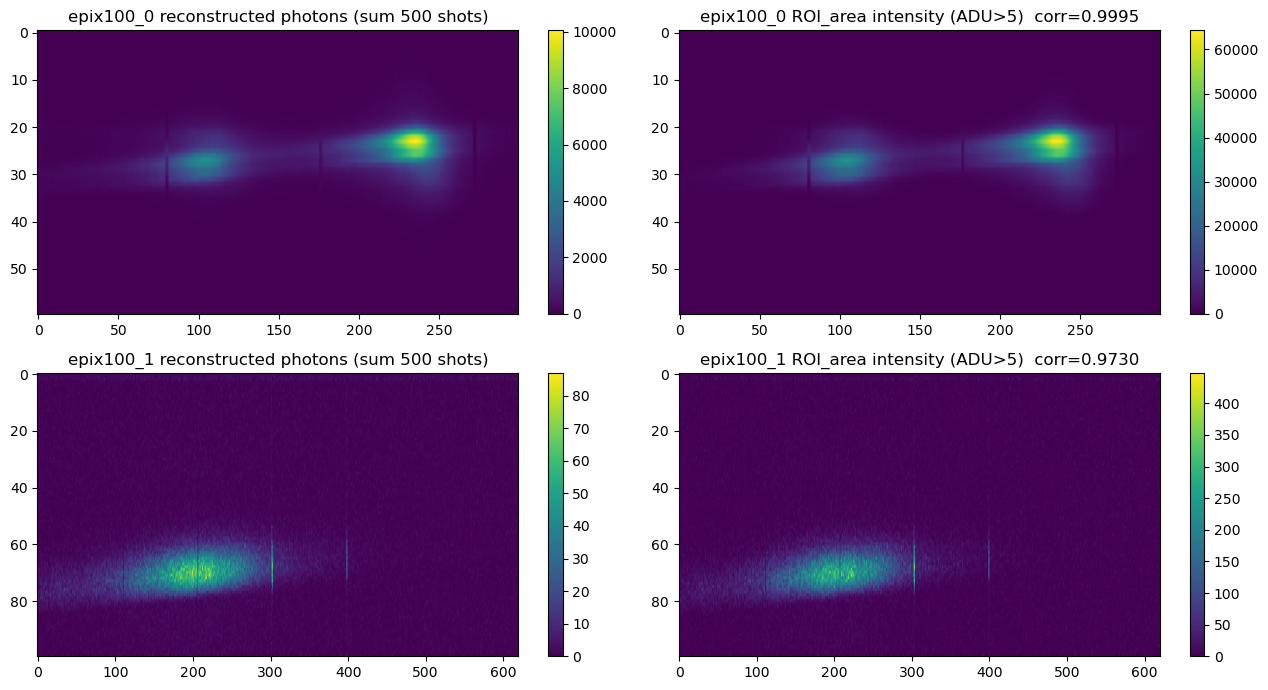

In [3]:
ADU_THRESH = 5.0
subset = xray_idx[:500]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for k, det in enumerate(['epix100_0', 'epix100_1']):
    roi = ROIS[det]
    photons = rec.sum_image(det, subset, roi=roi)
    inten = rec.f[f'{det}/ROI_area'][subset].astype(float)
    inten = np.nan_to_num(inten); inten[inten < ADU_THRESH] = 0
    inten = inten.sum(axis=0)
    corr = np.corrcoef(photons.ravel(), inten.ravel())[0, 1]

    a = axes[k, 0]
    im = a.imshow(photons, aspect='auto', cmap='viridis')
    a.set_title(f'{det} reconstructed photons (sum {len(subset)} shots)')
    plt.colorbar(im, ax=a)
    b = axes[k, 1]
    im = b.imshow(inten, aspect='auto', cmap='viridis')
    b.set_title(f'{det} ROI_area intensity (ADU>{ADU_THRESH:.0f})  corr={corr:.4f}')
    plt.colorbar(im, ax=b)
    print(f'{det}: 2D spatial correlation = {corr:.4f}')
plt.tight_layout(); plt.show()

## 3. Reconstruct a stack of xray-on shots

`reconstruct_many` returns `(Nshots, rows, cols)`.  Cropping to the ROI keeps the
arrays small; the full panel (704x768) is ~4 MB/shot so prefer `roi=` for large
selections.  Below: a small stack you can feed into per-shot analysis.

epix100_1 photon-counted stack: (2843, 100, 620)  (mean 944630 photons/shot)


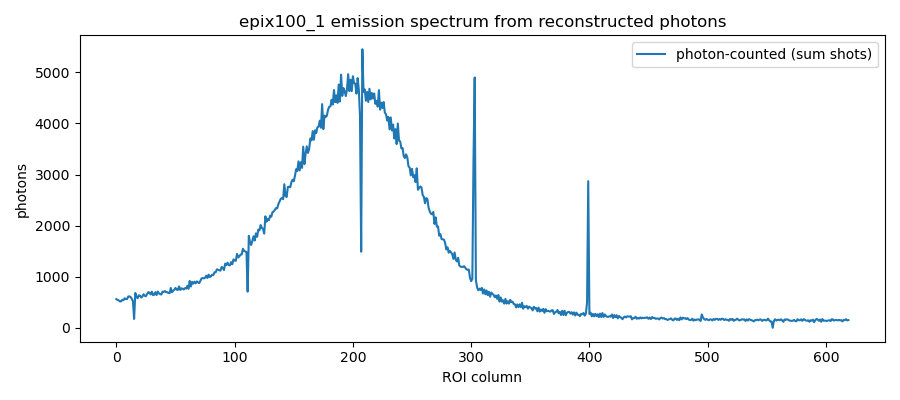

In [4]:
%matplotlib widget
det = 'epix100_1'
stack = rec.reconstruct_many(det, xray_idx[:], roi=ROIS[det])
print(f'{det} photon-counted stack: {stack.shape}  '
      f'(mean {stack.sum(axis=(1,2)).sum():.0f} photons/shot)')

# Per-shot 1D emission spectrum = project signal rows onto columns,
# the photon-counting analogue of the XES pipeline's reduce_detector_spatial.
SIGNAL_ROWS = {'epix100_0': (10, 40), 'epix100_1': (50, 90)}
r0, r1 = SIGNAL_ROWS[det]
spectra = stack[:, r0:r1, :].sum(axis=1)   # (Nshots, ROI_cols)

plt.figure(figsize=(9, 4))
plt.plot(spectra.sum(axis=0), label='photon-counted (sum shots)')
plt.xlabel('ROI column'); plt.ylabel('photons')
plt.title(f'{det} emission spectrum from reconstructed photons')
plt.legend(); plt.tight_layout(); plt.show()

## 4. Droplet vs non-droplet emission spectrum

Compare the droplet photon-counted spectrum (from cell 3) against the raw
ADU-thresholded `ROI_area` projection in `mfx101609126_seer_shot_browser.ipynb`,
over the **same 2843 xray-on shots** and the same SEER signal rows.

Magnitudes differ (photon counts vs summed ADU), so the two traces share an
x-axis (ROI column) but use separate y-axes.

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 620 and the array at index 1 has size 300

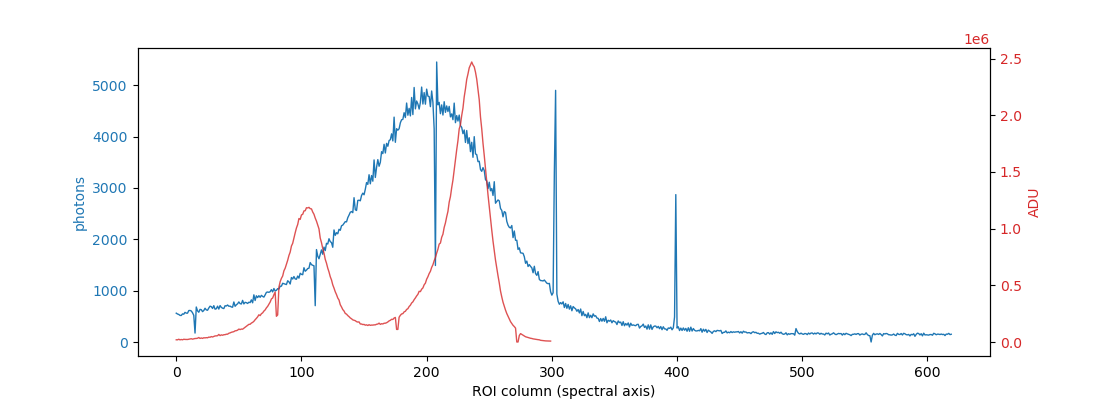

In [10]:
# Non-droplet reference: raw ADU-thresholded ROI_area, matching the SEER
# shot browser. ROI_area is already cropped to ROIS['epix100_1'] -> (N,100,620),
# so the same SIGNAL_ROWS slice and ROI columns line up with the droplet stack.
ADU_THRESH = 5.0
det = 'epix100_0'
r0, r1 = SIGNAL_ROWS[det]

# droplet photon-counted spectrum (summed over the 2843 xray-on shots)
droplet_spec = spectra.sum(axis=0)            # (ROI_cols,)

# raw ADU spectrum over the SAME xray-on shots
with h5py.File(SMD_PATH, 'r') as f:
    roi_area = f[f'{det}/ROI_area'][xray_idx].astype(np.float64)
roi_area = np.nan_to_num(roi_area)
roi_area[roi_area < ADU_THRESH] = 0.0
adu_spec = roi_area[:, r0:r1, :].sum(axis=(0, 1))   # (ROI_cols,)

fig, ax1 = plt.subplots(figsize=(11, 4))
c1, c2 = 'tab:blue', 'tab:red'
l1, = ax1.plot(droplet_spec, color=c1, lw=1.0, label='droplet (photon-counted)')
ax1.set_xlabel('ROI column (spectral axis)')
ax1.set_ylabel('photons', color=c1)
ax1.tick_params(axis='y', labelcolor=c1)

ax2 = ax1.twinx()
l2, = ax2.plot(adu_spec, color=c2, lw=1.0, alpha=0.8,
               label=f'non-droplet raw ADU (thresh={ADU_THRESH:g})')
ax2.set_ylabel('ADU', color=c2)
ax2.tick_params(axis='y', labelcolor=c2)

corr = np.corrcoef(droplet_spec, adu_spec)[0, 1]
ax1.set_title(f'{det} emission spectrum: droplet vs non-droplet  '
              f'({len(xray_idx)} xray-on shots, rows {r0}-{r1})  corr={corr:.4f}')
ax1.legend(handles=[l1, l2], loc='upper right')
plt.tight_layout(); plt.show()
print(f'1D spectral correlation (droplet vs raw ADU) = {corr:.4f}')

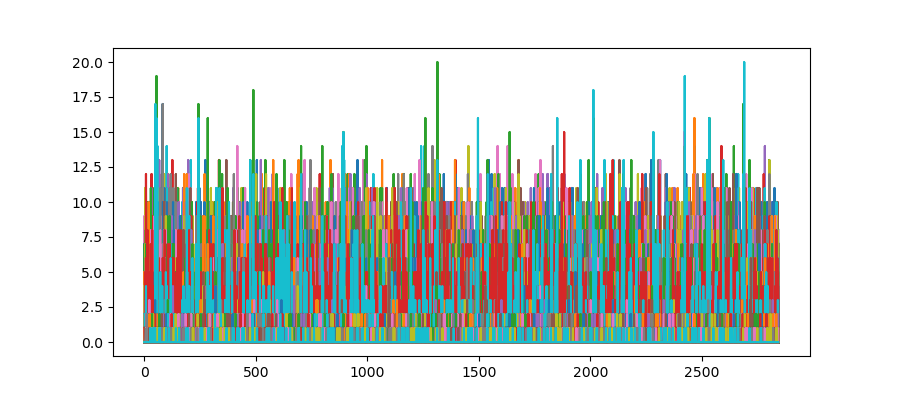

In [6]:
spectrum = stack[:, r0:r1, :]#.sum(axis=1)   # (Nshots, ROI_cols)

plt.figure(figsize=(9, 4))
#plt.imshow(spectrum, label='photon-counted (sum shots)')
for i in spectrum[:2]:
    plt.plot(np.nansum(spectrum,axis=1))

In [7]:
import matplotlib.pyplot as plt
plt.plot(np.nansum(np.nansum(spectrum,axis=0),axis=1))

In [8]:
    plt.plot(np.nansum(spectrum[:],axis=0))

In [9]:
np.shape(spectrum)

(2843, 40, 620)